# Setup

In [1]:
import warnings
import io
import contextlib
import json
import platform
import importlib.metadata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from IPython.display import display, Markdown
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank, VECM
from statsmodels.datasets import macrodata
from statsmodels.stats.multitest import multipletests
from statsmodels.tools.sm_exceptions import InterpolationWarning

# Keep numerical and model warnings visible. KPSS table bounds are handled explicitly below.
OUT = Path.cwd() / 'outputs' / 'm09-v2'
OUT.mkdir(parents=True, exist_ok=True)
VERSIONS = {name: importlib.metadata.version(name) for name in
            ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'nbformat', 'nbclient']}
print('Python:', platform.python_version())
display(pd.Series(VERSIONS, name='version'))

Python: 3.12.8


numpy           2.4.6
pandas          3.0.3
scipy          1.15.3
statsmodels    0.14.6
matplotlib     3.11.0
nbformat       5.11.1
nbclient       0.11.0
Name: version, dtype: str

This section of code prepares the environment and gathers information about installed packages.

First, it imports numerous libraries essential for data analysis, statistical modeling, and visualization. These include `numpy` for numerical operations, `pandas` for data manipulation, `matplotlib` for plotting, `statsmodels` for statistical models (particularly time series analysis), `scipy` for scientific computing, and tools for displaying output in environments like Jupyter notebooks (`IPython.display`). It also imports modules for file path handling (`pathlib`), JSON processing (`json`), managing warnings (`warnings`), context management (`contextlib`), and retrieving package metadata (`importlib.metadata`).

Next, it defines a directory `OUT` to store any outputs generated by the code, creating this directory if it doesn’t already exist. 

Following that, it creates a dictionary called `VERSIONS`. This dictionary stores the versions of several key Python packages used in the analysis: numpy, pandas, scipy, statsmodels, matplotlib, nbformat and nbclient. The version information is retrieved using `importlib.metadata.version()`.

Finally, the code prints the Python version being used and displays the package versions as a Pandas Series, providing a record of the software environment for reproducibility. This output is formatted to be easily readable in an interactive computing environment.

In [2]:
# general settings
class CFG:
    img_dim1 = 14          # default figure width
    img_dim2 = 6           # default figure height
    SEED     = 42          # global seed for reproducibility
    signif   = 0.05        # significance level used across all tests
    maxlags  = 8           # maximum lag order considered by selection criteria
    horizon  = 20          # forecast hold-out: 20 quarters = 5 years

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

This code block establishes general settings and visual preferences for a data analysis project.

A class named `CFG` is defined to encapsulate configuration parameters. Within this class, several attributes are set: `img_dim1` and `img_dim2` define the default dimensions (width and height) of figures created using Matplotlib; `SEED` sets a global random seed for ensuring reproducibility of results; `signif` specifies the significance level (alpha value) to be used in statistical tests, defaulting to 0.05; `maxlags` determines the maximum number of lags considered when performing time series analysis; and `horizon` defines the length of the forecast hold-out period, set to 20 quarters (equivalent to 5 years).

The code then modifies Matplotlib’s default style by applying “seaborn-v0_8”, enhancing the visual appearance of plots. It also adjusts the default figure size using the `img_dim1` and `img_dim2` values defined in the `CFG` class. 

Lastly, it sets the seed for NumPy's random number generator to the value specified by `CFG.SEED`, ensuring that any operations involving randomness will produce consistent results across multiple runs of the code.

# Utils


In [3]:
def forecast_metrics(actual, predicted):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    assert actual.shape == predicted.shape
    return {'MAE': float(np.abs(actual-predicted).mean()),
            'RMSE': float(np.sqrt(np.mean((actual-predicted)**2)))}

def export_table(frame, name):
    frame.to_csv(OUT / f'{name}.csv')
    display(frame)

def save_figure(name, fig=None):
    fig = plt.gcf() if fig is None else fig
    fig.tight_layout()
    fig.savefig(OUT / f'{name}.png', dpi=140, bbox_inches='tight')
    plt.show()

def var_diagnostics(result, name, horizons=(8, 12)):
    rows = []
    for h in horizons:
        if h <= result.k_ar:
            continue
        white = result.test_whiteness(nlags=h, adjusted=True)
        rows.append({'model': name, 'VAR_lags': result.k_ar,
                     'test_horizon': h, 'stable': bool(result.is_stable()),
                     'whiteness_p': float(white.pvalue),
                     'reject_no_autocorrelation': bool(white.pvalue < CFG.signif)})
    return pd.DataFrame(rows)

This code defines several functions to evaluate forecasts, export data, save figures, and perform diagnostic tests on VAR (Vector Autoregression) models.

The `forecast_metrics` function calculates two common forecast evaluation metrics: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). It takes the actual values and predicted values as input, converts them to NumPy arrays of floating-point numbers, asserts that they have the same shape, and then computes and returns a dictionary containing the MAE and RMSE.

The `export_table` function exports a Pandas DataFrame to a CSV file in the designated output directory (`OUT`) with a specified filename. It also displays the DataFrame in an interactive environment (like a Jupyter notebook). 

The `save_figure` function saves a Matplotlib figure to a PNG file in the output directory, ensuring that the layout is tight and the image has a resolution of 140 DPI. If no figure object is provided as input, it uses the current active figure (`plt.gcf()`). It also displays the figure on screen.

The `var_diagnostics` function performs diagnostic tests on a VAR model result object. It takes the VAR model result, a name for the model, and a tuple of horizons (number of lags) as input. For each horizon, it checks if the horizon is greater than the number of autoregressive lags in the model (`result.k_ar`). If so, it performs a whiteness test to check for autocorrelation in the residuals. The function then compiles the results of these tests into a list of dictionaries and returns them as a Pandas DataFrame. This DataFrame includes information about the model name, VAR lag order, test horizon, stability of the model, p-value from the whiteness test, and whether or not to reject the null hypothesis of no autocorrelation based on the specified significance level (`CFG.signif`).

In [4]:
def run_stationarity(df, signif=CFG.signif):
    rows = []
    for name in df:
        values = df[name].dropna()
        for deterministic in ['c', 'ct']:
            adf = adfuller(values, regression=deterministic, autolag='AIC')
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter('always', InterpolationWarning)
                kp = kpss(values, regression=deterministic, nlags='auto')
            bounded = any(issubclass(w.category, InterpolationWarning) for w in caught)
            for w in caught:
                if not issubclass(w.category, InterpolationWarning):
                    warnings.warn(w.message, w.category, stacklevel=2)
            bound = ('<= 0.01' if kp[1] == .01 else '>= 0.10') if bounded else 'interior'
            rows.append({'series': name, 'deterministic': deterministic,
                         'ADF p': adf[1], 'ADF lags': adf[2],
                         'ADF rejects unit root': adf[1] < signif,
                         'KPSS p': kp[1], 'KPSS bound': bound, 'KPSS lags': kp[2],
                         'KPSS rejects stationarity': kp[1] < signif})
    return pd.DataFrame(rows).set_index(['series', 'deterministic'])

This code defines a function `run_stationarity` that performs and reports the results of Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests for stationarity on each time series within a Pandas DataFrame.

The function takes a DataFrame (`df`) and an optional significance level (`signif`, defaulting to the value defined in `CFG`) as input. It iterates through each column (time series) in the DataFrame. For each series, it removes any missing values using `.dropna()`. 

It then loops through two deterministic trend specifications: 'c' (constant only) and 'ct' (constant and trend). Inside this loop, it performs both the ADF and KPSS tests on the time series with the specified deterministic component. The ADF test checks for a unit root (non-stationarity), while the KPSS test checks for stationarity around a trend.

The code includes careful handling of `InterpolationWarning` warnings that can arise during the ADF test, suppressing them temporarily to avoid cluttering the output but still capturing and re-issuing any other warnings. It also determines whether the KPSS test results fall within established bounds (<= 0.01 or >= 0.10) or are in the interior region where interpretation is less clear.

The function collects the p-values, lag orders, and rejection status (based on the specified significance level) from both tests for each deterministic trend specification. It then compiles these results into a list of dictionaries and returns them as a Pandas DataFrame with a multi-level index consisting of the series name and the deterministic component used in the test. This allows for easy comparison of stationarity results across different time series and trend specifications.

In [5]:
def train_valid_split(df, cutoff):
    """Chronological split. `cutoff` is positional; negative counts from the end."""
    return df.iloc[:cutoff].copy(), df.iloc[cutoff:].copy()

This code defines a function called `train_valid_split` that splits a Pandas DataFrame into training and validation sets based on a chronological order.

The function takes two arguments: a DataFrame (`df`) and a cutoff point (`cutoff`). The `cutoff` parameter specifies the index at which to split the data; negative values count from the end of the DataFrame. 

The function uses `.iloc[]` for integer-based indexing to select the rows before the `cutoff` as the training set and the rows from the `cutoff` onwards as the validation set. The `.copy()` method is used to create independent copies of the slices, preventing modifications to one set from affecting the other. 

The function then returns a tuple containing the training DataFrame and the validation DataFrame. This split is useful for time series analysis where maintaining the chronological order of data is crucial for both model training and evaluation.

In [6]:
def plot_multi(df, title, ylabel=""):
    """Consistent multi-series line plot: observed series as solid lines, lw=2."""
    ax = df.plot(linewidth=2, xlabel="")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    plt.legend(loc="best")
    plt.show()

This code defines a function `plot_multi` that generates a line plot of multiple time series contained within a Pandas DataFrame.

The function takes three arguments: the DataFrame (`df`) containing the time series data, a title for the plot (`title`), and an optional label for the y-axis (`ylabel`, defaulting to an empty string). 

It uses the `.plot()` method of the DataFrame to create a line plot of all columns in the DataFrame. The `linewidth` parameter is set to 2 to make the lines more visible. The x-axis label is removed using `xlabel=""`. It then sets the title and y-axis label for the plot using `ax.set_title()` and `ax.set_ylabel()`, respectively.

Finally, it adds a legend to the plot using `plt.legend(loc="best")` which automatically positions the legend in an optimal location within the plot area, and displays the plot using `plt.show()`. The function is designed to create consistent visualizations of multiple time series data with clear labeling and formatting.

In [7]:
def granger_pvalue(df, cause, effect, maxlag):
    with contextlib.redirect_stdout(io.StringIO()):
        out = grangercausalitytests(df[[effect, cause]], maxlag=maxlag)
    return {int(lag): float(out[lag][0]['ssr_ftest'][1]) for lag in out}

This code defines a function `granger_pvalue` that performs Granger causality tests between two time series and returns the p-values for different lag orders.

The function takes four arguments: a Pandas DataFrame (`df`) containing the time series data, the name of the potential cause variable (`cause`), the name of the potential effect variable (`effect`), and the maximum lag order to consider (`maxlag`). 

It uses `contextlib.redirect_stdout(io.StringIO())` to suppress the standard output from the `grangercausalitytests` function, preventing it from printing intermediate results to the console. This is done because only the p-values are needed as output.

The core of the function is a call to `grangercausalitytests`, which performs Granger causality tests for each lag order from 1 up to `maxlag`. The result (`out`) is a dictionary containing the test results for each lag.

The function then extracts the p-value from the F-test associated with each lag and stores it in a new dictionary, where the keys are the lag orders (as integers) and the values are the corresponding p-values (converted to floats). This dictionary of p-values is returned by the function. These p-values indicate the statistical significance of the Granger causality test at each lag order, helping determine if changes in the cause variable can predict changes in the effect variable.

In [8]:
def toda_yamamoto(df, cause, effect, p, d_max, signif=CFG.signif):
    if p < 1 or d_max < 0:
        raise ValueError('Require p >= 1 and d_max >= 0.')
    res = VAR(df).fit(p + d_max, trend='c')
    terms = [f'L{lag}.{cause}' for lag in range(1, p + 1)]
    # statsmodels interleaves equations within each regressor in cov_params().
    # Select the coefficient/covariance pairs by labels, never a contiguous equation block.
    keys = pd.MultiIndex.from_tuples([(term, effect) for term in terms])
    b = res.params.loc[terms, effect].to_numpy()
    V = res.cov_params().loc[keys, keys].to_numpy()
    wald = float(b @ np.linalg.solve(V, b))
    pvalue = float(stats.chi2.sf(wald, df=p))
    return {'wald': wald, 'df': p, 'p': pvalue,
            'reject_unadjusted': pvalue < signif}, res

This code defines a function `toda_yamamoto` that implements the Toda-Yamamoto Granger causality test. This test is designed to address potential issues with spurious regression in time series analysis when dealing with non-stationary data.

The function takes several arguments: a Pandas DataFrame (`df`) containing the time series data, the name of the potential cause variable (`cause`), the name of the potential effect variable (`effect`), the maximum lag order for the VAR model (`p`), the integration order (number of times differencing is needed to achieve stationarity) `d_max`, and an optional significance level (`signif`, defaulting to the value defined in `CFG`).

It first checks if the input parameters `p` and `d_max` are valid (greater than or equal to 1 and 0, respectively). If not, it raises a ValueError.

Then, it fits a Vector Autoregression (VAR) model to the data using `statsmodels.tsa.api.VAR`. The VAR model is fitted with `p + d_max` lags and includes a constant trend term (`trend='c'`).

Next, it constructs a list of terms representing lagged values of the cause variable (e.g., 'L1.cause', 'L2.cause', etc.). It then extracts the coefficients associated with these terms for the effect variable from the VAR model’s parameters (`res.params`) and their corresponding covariance matrix (`res.cov_params`).

The function calculates the Wald statistic, which tests the joint significance of the lagged cause variables in explaining the effect variable. This is done using the formula `b @ np.linalg.solve(V, b)`, where `b` is a vector of coefficients and `V` is the covariance matrix. 

It then computes the p-value associated with the Wald statistic using the chi-squared distribution (`stats.chi2.sf`). The p-value indicates the probability of observing a Wald statistic as large as or larger than the calculated value if there were no causal relationship between the cause and effect variables.

Finally, it returns a dictionary containing the Wald statistic, degrees of freedom (equal to `p`), p-value, and a boolean indicating whether to reject the null hypothesis of no causality based on the specified significance level (`signif`). It also returns the fitted VAR model object (`res`) for further analysis if needed.

# Groundwork

In [9]:
md_raw = macrodata.load_pandas().data
md_raw.index = pd.period_range("1959Q1", periods=len(md_raw), freq="Q")

# log levels: trending, non-stationary
levels = np.log(md_raw[["realgdp", "realcons", "realinv"]])
levels.columns = ["log_gdp", "log_cons", "log_inv"]

# growth rates: 100 * quarterly change in logs ~ percent per quarter
growth = (100 * levels.diff()).dropna()
growth.columns = ["g_gdp", "g_cons", "g_inv"]

print("full dataset:", md_raw.shape, " columns:", list(md_raw.columns))
levels.head(3)

full dataset: (203, 14)  columns: ['year', 'quarter', 'realgdp', 'realcons', 'realinv', 'realgovt', 'realdpi', 'cpi', 'm1', 'tbilrate', 'unemp', 'pop', 'infl', 'realint']


,log_gdp,log_cons,log_inv
1959Q1,7.904833,7.442727,5.659127
1959Q2,7.929775,7.458013,5.739339
1959Q3,7.928582,7.468399,5.667208


This code loads macroeconomic data, transforms it by taking logarithms and calculating growth rates, and then prints information about the resulting datasets.

First, it uses `macrodata.load_pandas().data` to load a pre-existing dataset of US macroeconomic time series from the `statsmodels` library. The index of this DataFrame (`md_raw`) is set to a quarterly period range starting in "1959Q1" with a length equal to the number of observations in the data, using a frequency of “Q” (quarterly).

Next, it takes the natural logarithm of three columns from `md_raw`: "realgdp", "realcons", and "realinv". These represent real gross domestic product, real consumption, and real investment, respectively. The resulting DataFrame is stored in `levels`, and its column names are changed to "log_gdp", "log_cons", and "log_inv". Taking the logarithm helps stabilize the variance of these time series and can make them more stationary.

Then, it calculates the quarterly growth rates of the logged variables by taking the first difference (the change from one period to the next) and multiplying by 100. This effectively converts the changes in logs into approximate percentage changes per quarter. Any rows with missing values resulting from the differencing operation are removed using `.dropna()`. The resulting DataFrame is stored in `growth`, and its column names are changed to "g_gdp", "g_cons", and "g_inv".

Finally, it prints information about the original dataset (`md_raw`), including its shape (number of rows and columns) and a list of its column names. It then displays the first three rows of the `levels` DataFrame using `.head(3)` to provide a quick preview of the transformed data.

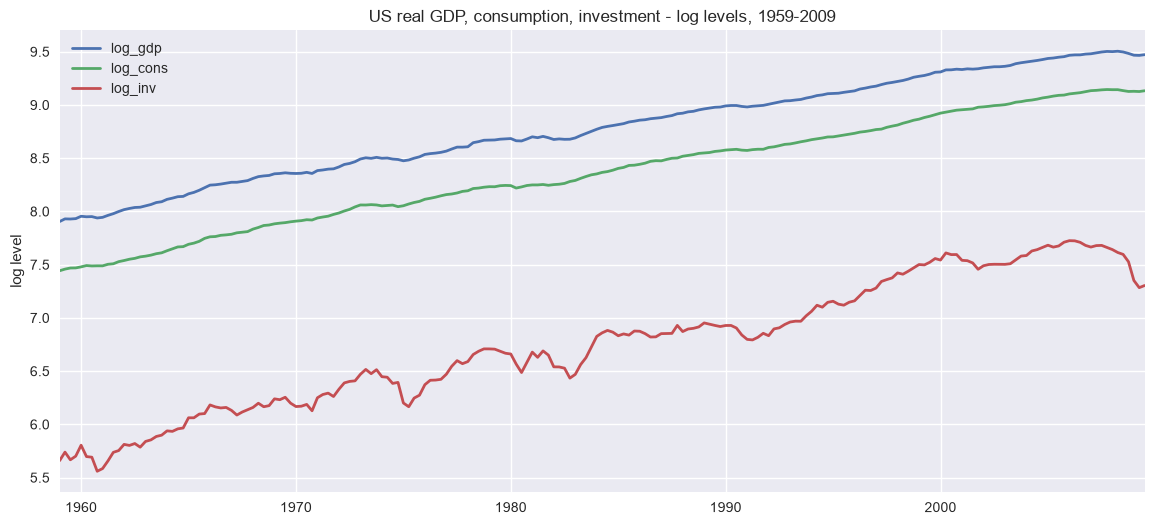

In [10]:
plot_multi(levels, "US real GDP, consumption, investment - log levels, 1959-2009",
           ylabel="log level")

This code generates a line plot visualizing the logged levels of US real GDP, consumption, and investment from 1959 to 2009.

It calls the `plot_multi` function, passing in the `levels` DataFrame (which contains the logarithmically transformed data), a title for the plot ("US real GDP, consumption, investment - log levels, 1959-2009"), and a label for the y-axis ("log level").

The `plot_multi` function then creates a line plot with each time series (log_gdp, log_cons, and log_inv) represented as a solid line with a linewidth of 2. The x-axis is unlabeled, and the plot includes a title, y-axis label, and a legend to identify each series. Finally, the plot is displayed on screen. This visualization allows for a quick assessment of the trends and relationships between these macroeconomic variables in their logged forms.

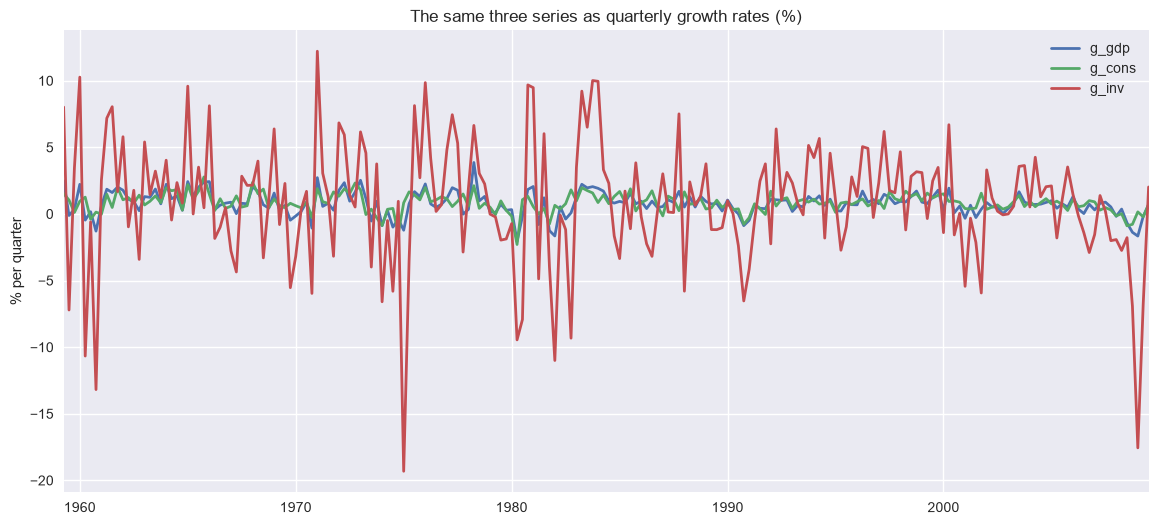

In [11]:
plot_multi(growth, "The same three series as quarterly growth rates (%)",
           ylabel="% per quarter")

This code generates a line plot visualizing the quarterly growth rates of US real GDP, consumption, and investment from 1959 to 2009.

It calls the `plot_multi` function, passing in the `growth` DataFrame (which contains the calculated growth rates), a title for the plot ("The same three series as quarterly growth rates (%)"), and a label for the y-axis ("% per quarter").

The `plot_multi` function then creates a line plot with each time series (g_gdp, g_cons, and g_inv) represented as a solid line with a linewidth of 2. The x-axis is unlabeled, and the plot includes a title, y-axis label, and a legend to identify each series. Finally, the plot is displayed on screen. This visualization allows for an assessment of the fluctuations and relationships between these macroeconomic variables in terms of their quarterly growth rates.

In [12]:
lv = run_stationarity(levels)
gr = run_stationarity(growth)
stationarity = pd.concat({'log levels': lv, 'quarterly growth': gr}, names=['representation'])
export_table(stationarity, 'stationarity_macro')

ADF p  ADF lags  \
representation   series   deterministic                           
log levels       log_gdp  c              3.827723e-01         2   
                          ct             3.887635e-01         2   
                 log_cons c              4.596836e-01         3   
                          ct             3.086447e-01         3   
                 log_inv  c              5.693619e-01         1   
                          ct             1.240353e-01         3   
quarterly growth g_gdp    c              8.575096e-10         1   
                          ct             5.355074e-09         1   
                 g_cons   c              2.301965e-05         2   
                          ct             8.277323e-05         2   
                 g_inv    c              1.118658e-22         0   
                          ct             1.486492e-19         0   

                                         ADF rejects unit root    KPSS p  \
representation   series   deterministic                                    
log levels       log_gdp  c                              False  0.010000   
                          ct                             False  0.013242   
                 log_cons c                              False  0.010000   
                          ct                             False  0.010000   
                 log_inv  c                              False  0.010000   
                          ct                             False  0.100000   
quarterly growth g_gdp    c                               True  0.100000   
                          ct                              True  0.100000   
                 g_cons   c                               True  0.100000   
                          ct                              True  0.100000   
                 g_inv    c                               True  0.100000   
                          ct                              True  0.100000   

                                        KPSS bound  KPSS lags  \
representation   series   deterministic                         
log levels       log_gdp  c                <= 0.01          9   
                          ct              interior          9   
                 log_cons c                <= 0.01          9   
                          ct               <= 0.01          9   
                 log_inv  c                <= 0.01          9   
                          ct               >= 0.10          8   
quarterly growth g_gdp    c                >= 0.10          6   
                          ct               >= 0.10          6   
                 g_cons   c                >= 0.10          7   
                          ct               >= 0.10          7   
                 g_inv    c                >= 0.10          4   
                          ct               >= 0.10          4   

                                         KPSS rejects stationarity  
representation   series   deterministic                             
log levels       log_gdp  c                                   True  
                          ct                                  True  
                 log_cons c                                   True  
                          ct                                  True  
                 log_inv  c                                   True  
                          ct                                 False  
quarterly growth g_gdp    c                                  False  
                          ct                                 False  
                 g_cons   c                                  False  
                          ct                                 False  
                 g_inv    c                                  False  
                          ct                                 False

This code performs stationarity tests on both the logged level data and the growth rate data, then combines the results into a single table for export.

First, it calls the `run_stationarity` function with the `levels` DataFrame as input to perform Augmented Dickey-Fuller (ADF) and Kwiatkowski-Phillips-Schmidt-Shin (KPSS) tests on each of the logged time series ("log_gdp", "log_cons", "log_inv"). The results are stored in the `lv` variable.

Next, it calls the `run_stationarity` function again, this time with the `growth` DataFrame as input, to perform the same stationarity tests on the quarterly growth rates ("g_gdp", "g_cons", "g_inv"). The results are stored in the `gr` variable.

Then, it concatenates the two resulting DataFrames (`lv` and `gr`) along a new level of the index named 'representation'. This creates a single DataFrame called `stationarity`, where one level of the index indicates whether the data represents "log levels" or "quarterly growth", and the other level identifies the specific time series.

Finally, it calls the `export_table` function to export this combined `stationarity` DataFrame to a CSV file named "stationarity_macro" in the output directory (`OUT`) and displays the table in an interactive environment (like a Jupyter notebook). This allows for easy comparison of the stationarity test results across different data representations.

# Vector Autoregression

## A single equation: AR(1)

In [13]:
AR_LAGS = [1]                      # a pure AR(1): regress on lag 1 only

single_eq = AutoReg(growth["g_gdp"], lags=AR_LAGS, old_names=False).fit()
single_eq.params

const       0.533054
g_gdp.L1    0.301710
dtype: float64

The AR(1) is an explanatory baseline for GDP growth, fitted here to the full sample. Its fitted
persistence is an association. The forecast comparison below separately re-estimates every model
on training data; this full-sample fit is not used to forecast the holdout.

## The full system: VAR(p)


In [14]:
train, valid = train_valid_split(growth, -CFG.horizon)
order_sel = VAR(train).select_order(maxlags=CFG.maxlags)
print('Lag selection uses training data only:', train.index.min(), 'to', train.index.max())
print('Holdout:', valid.index.min(), 'to', valid.index.max())
display(order_sel.summary())

Lag selection uses training data only: 1959Q2 to 2004Q3
Holdout: 2004Q4 to 2009Q3


,AIC,BIC,FPE,HQIC
0,-0.1113,-0.05684,0.8947,-0.08921
1,-0.3434*,-0.1255*,0.7094*,-0.2550*
2,-0.3121,0.06917,0.7320,-0.1574
3,-0.2939,0.2507,0.7456,-0.07298
4,-0.2867,0.4213,0.7513,0.0005068
5,-0.2879,0.5836,0.7510,0.06565
6,-0.2407,0.7941,0.7881,0.1791
7,-0.2224,0.9759,0.8039,0.2637
8,-0.2377,1.124,0.7932,0.3146


Lower information criteria are preferred. BIC chooses the forecasting lag using only the
training period. For this dataset the criteria agree on one lag; this does not guarantee model
adequacy. The same lag is retained for the full-sample explanatory fit and diagnosed separately.

In [15]:
VAR_LAG = int(order_sel.selected_orders['bic'])
assert VAR_LAG >= 1, 'A zero-lag selection needs a different lag-test demonstration.'
var_res = VAR(growth).fit(VAR_LAG)
display(var_res.summary())
growth_diagnostics = var_diagnostics(var_res, 'Growth VAR')
export_table(growth_diagnostics, 'growth_var_diagnostics')
growth_adequate = bool(growth_diagnostics.stable.all() and
                       not growth_diagnostics.reject_no_autocorrelation.any())
print('Growth VAR passes these limited adequacy screens:', growth_adequate)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 27, Sep, 2026
Time:                     22:51:32
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.107734
Nobs:                     201.000    HQIC:                 -0.225146
Log likelihood:          -812.973    FPE:                   0.737174
AIC:                    -0.304946    Det(Omega_mle):        0.694859
--------------------------------------------------------------------
Results for equation g_gdp
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const             0.357952         0.091137            3.928           0.000
L1.g_gdp         -0.338056         0.172084           -1.964           0.049
L1.g_cons         0.746283         0.130411            5.723           0.000

,model,VAR_lags,test_horizon,stable,whiteness_p,reject_no_autocorrelation
0,Growth VAR,1,8,True,0.025243,True
1,Growth VAR,1,12,True,0.042856,True


Growth VAR passes these limited adequacy screens: False


The full-sample growth VAR is stable but rejects residual whiteness at the reported horizons.
Consequently its conventional Granger p-values are conditional diagnostics, not robust findings.
Coefficient magnitude is not predictive importance or a causal effect. Lagged consumption's
association cannot establish a household-expectations mechanism. We report failures rather than
searching for a specification that produces the preferred conclusion.

In [16]:
# One origin: forecast all 20 held-out quarters without updating either model.
# train and valid were defined BEFORE lag selection above.
assert train.index.max() < valid.index.min()
pred_single = pd.DataFrame(index=valid.index, columns=growth.columns, dtype=float)
for col in growth:
    pred_single[col] = AutoReg(train[col], lags=AR_LAGS, old_names=False).fit().forecast(CFG.horizon).to_numpy()
var_tr = VAR(train).fit(VAR_LAG)
pred_joint = pd.DataFrame(var_tr.forecast(train.to_numpy()[-VAR_LAG:], CFG.horizon),
                          index=valid.index, columns=growth.columns)
assert pred_single.notna().all().all() and pred_joint.notna().all().all()
assert pred_single.index.equals(valid.index) and pred_joint.index.equals(valid.index)
display(pd.concat({'actual': valid, 'AR': pred_single, 'VAR': pred_joint}, axis=1).head())

actual                            AR                           VAR  \
           g_gdp    g_cons     g_inv     g_gdp    g_cons     g_inv     g_gdp   
2004Q4  0.863887  1.143534  2.040341  0.797194  0.873969  1.066565  0.842342   
2005Q1  0.992864  0.745980  2.102162  0.813434  0.879166  1.049060  0.825941   
2005Q2  0.425307  0.957666 -1.805400  0.817471  0.880405  1.047677  0.822586   
2005Q3  0.756754  0.709741  1.095611  0.818474  0.880700  1.047568  0.820593   
2005Q4  0.515465  0.257969  3.521745  0.818723  0.880771  1.047560  0.819961   

                            
          g_cons     g_inv  
2004Q4  0.887170  1.208051  
2005Q1  0.885305  1.067337  
2005Q2  0.881645  1.057283  
2005Q3  0.880668  1.045887  
2005Q4  0.880215  1.042957

This is a retrospective, single-origin, 20-step forecast experiment ending in 2009Q3. Forecasts
use neither realized future values nor future-based lag selection. It is not a sequence of
one-quarter-ahead forecasts and does not reproduce the vintages available to a forecaster in 2004.

,AR RMSE,VAR RMSE,VAR minus AR RMSE
series,,,
g_gdp,0.927170,0.927493,0.000322
g_cons,0.745862,0.745142,-0.000721
g_inv,5.287632,5.283012,-0.004620


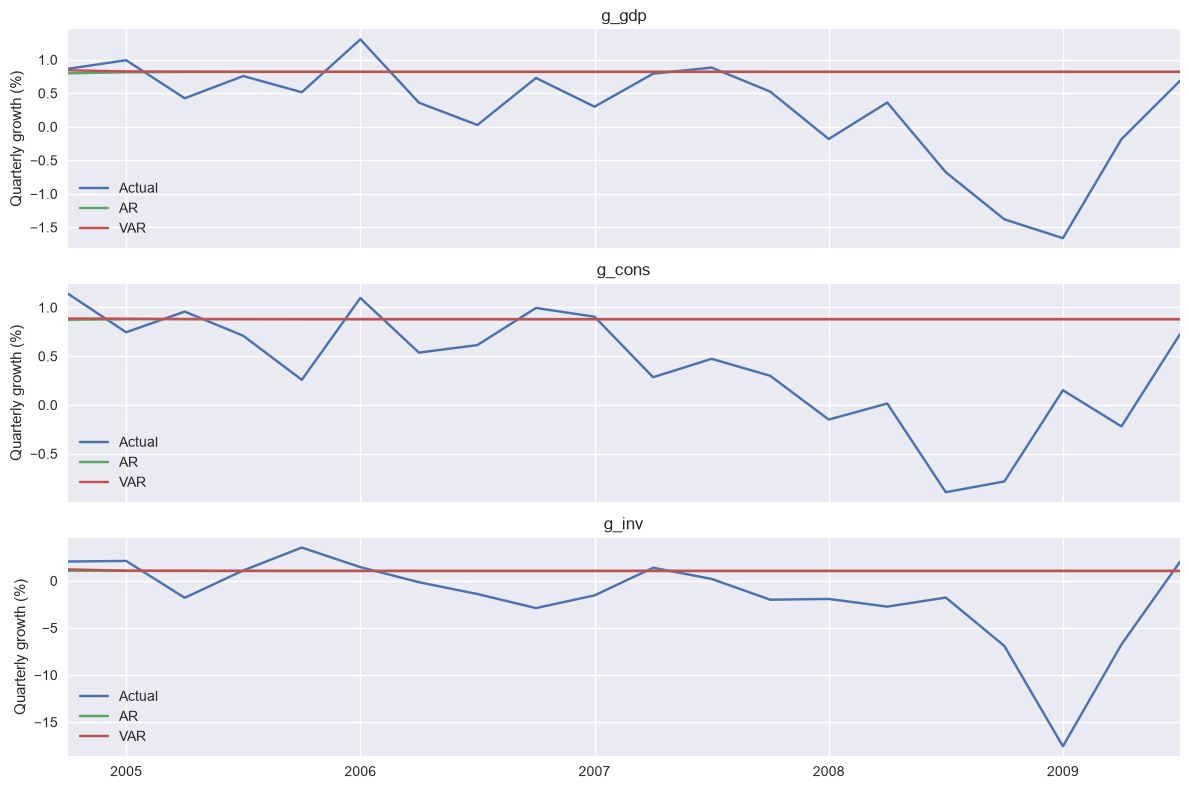

In [17]:
comparison = pd.DataFrame([
    {'series': col,
     'AR RMSE': forecast_metrics(valid[col], pred_single[col])['RMSE'],
     'VAR RMSE': forecast_metrics(valid[col], pred_joint[col])['RMSE']}
    for col in growth]).set_index('series')
comparison['VAR minus AR RMSE'] = comparison['VAR RMSE'] - comparison['AR RMSE']
export_table(comparison, 'forecast_comparison')
forecast_paths = pd.concat({'actual': valid, 'AR': pred_single, 'VAR': pred_joint}, axis=1)
forecast_paths.to_csv(OUT / 'forecast_paths.csv')
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col in zip(axes, growth):
    pd.DataFrame({'Actual': valid[col], 'AR': pred_single[col], 'VAR': pred_joint[col]}).plot(ax=ax)
    ax.set_title(col); ax.set_ylabel('Quarterly growth (%)')
save_figure('forecast_paths', fig)

The RMSE differences are tiny relative to the errors and come from one forecast origin.
They do not establish a reliable advantage. Rolling-origin evaluation with horizon-specific
metrics would be a useful extension; it is not claimed to have been performed here.

# Granger causality



## Bivariate Granger causality


In [18]:
GRANGER_MAXLAG = 4          # test at every lag from 1 to 4 quarters

print("does consumption growth lead GDP growth?")
print("   g_cons -> g_gdp :", granger_pvalue(growth, cause="g_cons", effect="g_gdp",
                                             maxlag=GRANGER_MAXLAG))
print("does GDP growth lead consumption growth?")
print("   g_gdp -> g_cons :", granger_pvalue(growth, cause="g_gdp", effect="g_cons",
                                             maxlag=GRANGER_MAXLAG))

does consumption growth lead GDP growth?
   g_cons -> g_gdp : {1: 2.0418103098395876e-07, 2: 2.8076149148442495e-08, 3: 4.7987294316873364e-08, 4: 4.797110683675056e-08}
does GDP growth lead consumption growth?
   g_gdp -> g_cons : {1: 0.09121322302946276, 2: 0.7844327580357571, 3: 0.36920088914451415, 4: 0.26371421596962896}


The consumption-to-GDP null is rejected across the displayed lag orders; that does not mean
each individual lag is significant. Non-rejection in the reverse direction is not proof of no
predictive content. These exploratory results do not identify interventions or a mechanism.

In [19]:
print("does investment growth lead consumption growth?")
print("   g_inv -> g_cons :", granger_pvalue(growth, cause="g_inv", effect="g_cons",
                                             maxlag=GRANGER_MAXLAG))

does investment growth lead consumption growth?
   g_inv -> g_cons : {1: 0.015328641225121094, 2: 0.3585390102727906, 3: 0.8533382942867807, 4: 0.8467138498605504}


The investment-to-consumption result depends on lag specification. Conditioning on GDP changes
the observed information set, but does not remove every omitted common cause. The lag search
is exploratory and is not covered by the six-test correction below.

## Conditional (multivariate) Granger causality

In [20]:
labels = growth.columns
gc_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)
for eff in labels:
    for cau in labels:
        if eff == cau:
            gc_matrix.loc[eff, cau] = np.nan          # own-lags are not a causal claim
        else:
            gc_matrix.loc[eff, cau] = var_res.test_causality(eff, cau).pvalue

gc_matrix.round(3)          # rows = effect, columns = cause; small p => "cause -> effect"

,g_gdp,g_cons,g_inv
g_gdp,NaN,0.0,0.023
g_cons,0.360,NaN,0.049
g_inv,0.014,0.0,NaN


These tests ask whether a cross-lag block contributes conditional predictive information within
the fitted system. With one lag they address a single coefficient restriction, but the VAR
coefficient table and system F-test use different reference distributions, so their p-values
need not be numerically identical. Residual misspecification limits conventional inference.

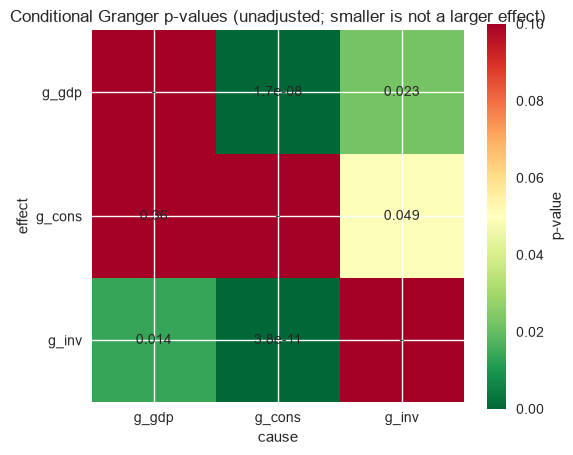

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(gc_matrix.fillna(1.0).astype(float).values,
               cmap="RdYlGn_r", vmin=0, vmax=0.1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
ax.set_xlabel("cause"); ax.set_ylabel("effect")
ax.set_title("Conditional Granger p-values (unadjusted; smaller is not a larger effect)")
for i in range(len(labels)):
    for j in range(len(labels)):
        v = gc_matrix.iloc[i, j]
        ax.text(j, i, "-" if np.isnan(v) else f"{v:.2g}",
                ha="center", va="center", zorder=3)
fig.colorbar(im, ax=ax, label="p-value")
plt.show()

The heatmap displays unadjusted p-values, not effect magnitudes. Very small p-values are shown
in scientific notation rather than as zero. The displayed links remain conditional on the VAR.

In [22]:
gc_tests = pd.DataFrame([
    {'cause': cause, 'effect': effect, 'p': gc_matrix.loc[effect, cause]}
    for effect in labels for cause in labels if effect != cause])
N_TESTS = len(gc_tests)
gc_tests['p_bonferroni'] = multipletests(gc_tests.p, method='bonferroni')[1]
gc_tests['p_holm'] = multipletests(gc_tests.p, method='holm')[1]
gc_tests['reject_holm'] = gc_tests.p_holm < CFG.signif
gc_tests['VAR_diagnostics_pass'] = growth_adequate
export_table(gc_tests, 'conditional_granger')

,cause,effect,p,p_bonferroni,p_holm,reject_holm,VAR_diagnostics_pass
0,g_cons,g_gdp,1.669203e-08,1.001522e-07,8.346017e-08,True,False
1,g_inv,g_gdp,2.262825e-02,1.357695e-01,6.788475e-02,False,False
2,g_gdp,g_cons,3.598410e-01,1.000000e+00,3.598410e-01,False,False
3,g_inv,g_cons,4.893249e-02,2.935949e-01,9.786498e-02,False,False
4,g_gdp,g_inv,1.368088e-02,8.208528e-02,5.472352e-02,False,False
5,g_cons,g_inv,3.811531e-11,2.286918e-10,2.286918e-10,True,False


Bonferroni and Holm control family-wise error without assuming independent tests, provided the
individual p-values are valid. Holm is at least as powerful as Bonferroni. These corrections
cover the six stated directional tests, not all earlier exploratory choices. Surviving correction
does not repair residual misspecification or establish causality.

# Cointegration



## The spurious regression trap

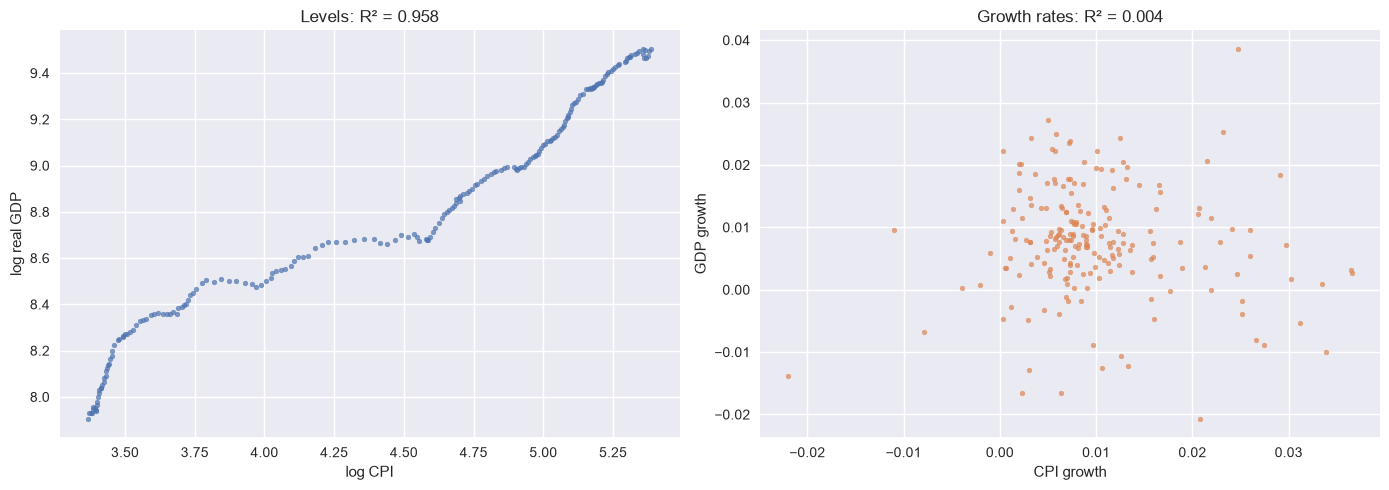

R² in levels: 0.958    R² in growth rates: 0.004


In [23]:
log_cpi = np.log(md_raw["cpi"])

# levels regression: log real GDP on log CPI
X_lvl = sm.add_constant(log_cpi.values)
r2_lvl = sm.OLS(levels["log_gdp"].values, X_lvl).fit().rsquared

# the same regression on growth rates
g_gdp_, g_cpi_ = levels["log_gdp"].diff().dropna(), log_cpi.diff().dropna()
r2_gr = sm.OLS(g_gdp_.values, sm.add_constant(g_cpi_.values)).fit().rsquared

fig, axes = plt.subplots(1, 2, figsize=(CFG.img_dim1, 5))
axes[0].scatter(log_cpi, levels["log_gdp"], s=12, alpha=0.7)
axes[0].set(title=f"Levels: R² = {r2_lvl:.3f}", xlabel="log CPI", ylabel="log real GDP")
axes[1].scatter(g_cpi_, g_gdp_, s=12, alpha=0.7, color="#DD8452")
axes[1].set(title=f"Growth rates: R² = {r2_gr:.3f}", xlabel="CPI growth", ylabel="GDP growth")
plt.tight_layout(); plt.show()

print(f"R² in levels: {r2_lvl:.3f}    R² in growth rates: {r2_gr:.3f}")

The levels/growth R² contrast illustrates the influence of persistence. It does not prove that
GDP and CPI have no economic relationship, or demonstrate spurious regression with known ground
truth. Independent simulated random walks would provide that controlled demonstration.

## Engle–Granger: the two-step test

In [24]:
log_m1 = np.log(md_raw['m1'])
eg_results = pd.DataFrame([
    {'pair': 'consumption / GDP', 'p': coint(levels.log_cons, levels.log_gdp)[1]},
    {'pair': 'investment / M1', 'p': coint(levels.log_inv, log_m1)[1]}])
eg_results['reject_no_cointegration_unadjusted'] = eg_results.p < CFG.signif
export_table(eg_results, 'engle_granger')

,pair,p,reject_no_cointegration_unadjusted
0,consumption / GDP,0.029407,True
1,investment / M1,0.214545,False


`coint` uses residual-based cointegration critical values; an ordinary ADF p-value on estimated
residuals is not a substitute. The consumption/GDP result rejects no cointegration under this
specification, while investment/M1 does not. Non-rejection is not evidence of no relationship.
A stationary consumption/GDP ratio requires a specific (1, −1) log-level restriction, which
unrestricted cointegration does not test. These pair checks are exploratory, unadjusted results.



## Johansen: system-wide cointegration

In [25]:
DET_ORDER = 0          # unrestricted constant case; match VECM deterministic="co"
K_AR_DIFF = 2          # short-run lags (in differences) for the underlying VECM

joh = coint_johansen(levels, det_order=DET_ORDER, k_ar_diff=K_AR_DIFF)

trace_table = pd.DataFrame({
    "null hypothesis": [f"rank <= {i}" for i in range(levels.shape[1])],
    "trace statistic": np.round(joh.lr1, 2),
    "5% critical value": np.round(joh.cvt[:, 1], 2),
    "reject?": joh.lr1 > joh.cvt[:, 1],
})
selected = select_coint_rank(levels, det_order=DET_ORDER, k_ar_diff=K_AR_DIFF,
                             method="trace", signif=CFG.signif)
print("selected cointegration rank:", selected.rank)
trace_table

selected cointegration rank: 1


,null hypothesis,trace statistic,5% critical value,reject?
0,rank <= 0,30.64,29.80,True
1,rank <= 1,10.55,15.49,False
2,rank <= 2,2.96,3.84,False


The rank-one decision is marginal and conditional on the deterministic terms and two lagged
differences. In this implementation the constant Johansen case is matched to VECM `co`, not `ci`.
`k_ar_diff=2` corresponds to a levels VAR order of three. A full-rank finding would challenge the
maintained all-I(1) model; a rank estimate is not a certainty about economic equilibrium.

In [26]:
grid = pd.DataFrame(index=[f"det_order={d}" for d in (0, 1)],
                    columns=[f"k_ar_diff={k}" for k in (1, 2, 3, 4)], dtype=int)
for d in (0, 1):
    for k in (1, 2, 3, 4):
        grid.loc[f"det_order={d}", f"k_ar_diff={k}"] = select_coint_rank(
            levels, det_order=d, k_ar_diff=k, method="trace", signif=CFG.signif).rank
grid.astype(int)          # selected rank under each specification

,k_ar_diff=1,k_ar_diff=2,k_ar_diff=3,k_ar_diff=4
det_order=0,0,1,1,1
det_order=1,0,0,0,1


The grid exposes sensitivity to deterministic terms and lag order. It is not a vote whose most
frequent rank settles the issue. Rank one is retained below as a labelled conditional illustration,
not selected because it is the most attractive result. The deterministic cases are alternative
models, not interchangeable settings.

# Vector Error Correction: dynamics tethered to equilibrium


In [27]:
COINT_RANK = int(selected.rank)
vecm_res = None
if 0 < COINT_RANK < levels.shape[1]:
    vecm_res = VECM(levels, k_ar_diff=K_AR_DIFF, coint_rank=COINT_RANK,
                    deterministic='co').fit()
    rows = []
    for relation in range(COINT_RANK):
        for i, name in enumerate(levels):
            rows.append({'series': name, 'relation': relation+1,
                         'beta': vecm_res.beta[i, relation],
                         'beta_se': vecm_res.stderr_beta[i, relation],
                         'alpha': vecm_res.alpha[i, relation],
                         'alpha_se': vecm_res.stderr_alpha[i, relation],
                         'alpha_p': vecm_res.pvalues_alpha[i, relation]})
    export_table(pd.DataFrame(rows), 'vecm_coefficients')
    export_table(pd.DataFrame({'series': list(levels),
                              'unrestricted_constant': vecm_res.det_coef[:, 0],
                              'constant_se': vecm_res.stderr_det_coef[:, 0]}), 'vecm_constants')
    print('Conditional VECM residual whiteness p:', vecm_res.test_whiteness(12, adjusted=True).pvalue)
    if COINT_RANK == 1:
        joh_beta = joh.evec[:, 0] / joh.evec[0, 0]
        np.testing.assert_allclose(vecm_res.beta[:, 0], joh_beta, atol=1e-7)
else:
    print('No reduced-rank VECM fitted: selected rank is', COINT_RANK)

,series,relation,beta,beta_se,alpha,alpha_se,alpha_p
0,log_gdp,1,1.000000,0.000000,-0.024501,0.008761,0.005165
1,log_cons,1,-1.707073,0.191147,-0.003907,0.007729,0.613235
2,log_inv,1,0.648799,0.158357,-0.199103,0.044621,0.000008


,series,unrestricted_constant,constant_se
0,log_gdp,-0.026213,0.009978
1,log_cons,0.001036,0.008802
2,log_inv,-0.249329,0.050818


Conditional VECM residual whiteness p: 0.09122182180051476


The corrected `co` fit matches the rank-test specification and changes both beta and alpha.
Alpha is the response of an equation's change to one unit of the normalized error-correction
term, not generally a fraction of the system-wide gap closed per quarter. Interpretation depends
on normalization and all dynamics. Beta coefficients are not GDP component shares. The coefficient
uncertainty is conditional on the selected rank and specification, which remain uncertain.

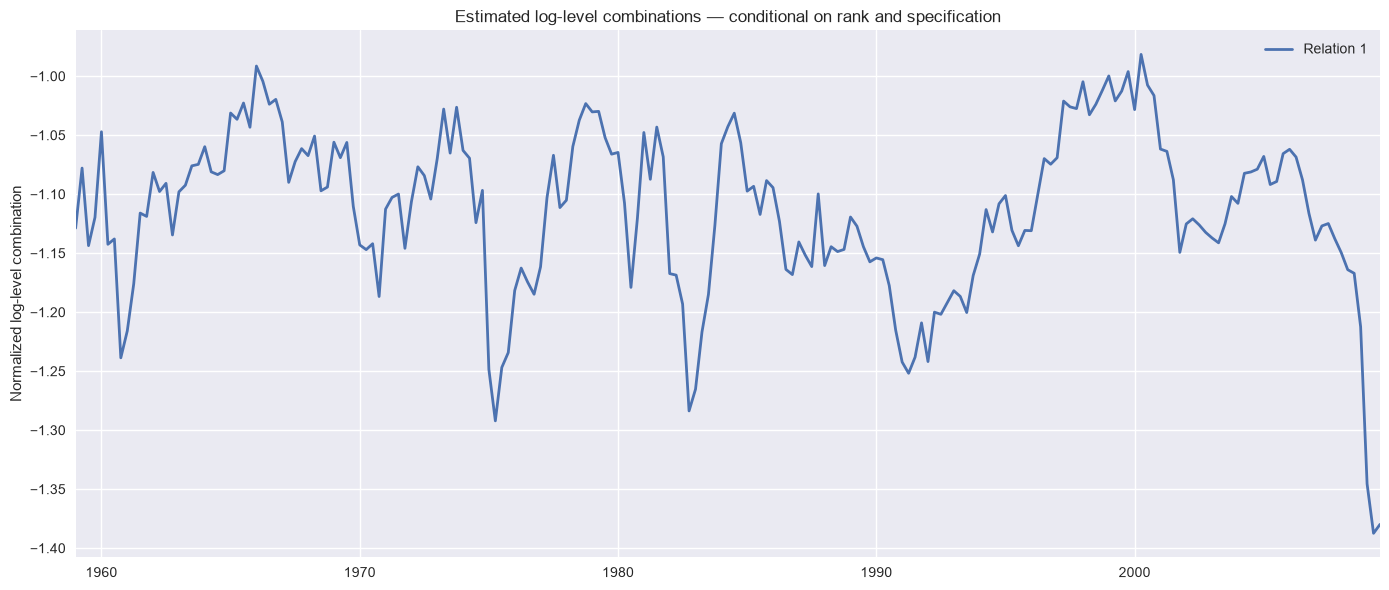

In [28]:
if vecm_res is not None:
    # 'co' has no deterministic terms inside the cointegrating relation.
    assert vecm_res.det_coef_coint.size == 0
    relations = pd.DataFrame(levels.to_numpy() @ vecm_res.beta,
        index=levels.index, columns=[f'Relation {j+1}' for j in range(COINT_RANK)])
    ax = relations.plot(linewidth=2, xlabel='')
    ax.set_title('Estimated log-level combinations — conditional on rank and specification')
    ax.set_ylabel('Normalized log-level combination')
    save_figure('vecm_relations')
    relations.to_csv(OUT / 'vecm_relations.csv')

The combinations are plotted descriptively. We remove the ordinary ADF test of the estimated
spread: its usual p-value is not calibrated for a cointegrating vector estimated from these same
data. Non-rejection would not establish a unit root anyway. The rank sensitivity remains the
reason for caution. A separate `ci` model would require its restricted intercept in the
error-correction term, but adding that intercept would not solve the inference problem.

# Toda–Yamamoto: causality without the pre-test minefield


In [29]:
money = pd.concat([log_m1, levels['log_gdp']], axis=1)
money.columns = ['log_m1', 'log_gdp']
money_stationarity = pd.concat({'levels': run_stationarity(money),
                               'first differences': run_stationarity(money.diff().dropna())},
                              names=['representation'])
export_table(money_stationarity, 'money_stationarity')

ADF p  ADF lags  \
representation    series  deterministic                           
levels            log_m1  c              8.238873e-01         8   
                          ct             7.194235e-01         5   
                  log_gdp c              3.827723e-01         2   
                          ct             3.887635e-01         2   
first differences log_m1  c              2.296416e-03         7   
                          ct             1.217538e-02         7   
                  log_gdp c              8.575096e-10         1   
                          ct             5.355074e-09         1   

                                         ADF rejects unit root    KPSS p  \
representation    series  deterministic                                    
levels            log_m1  c                              False  0.010000   
                          ct                             False  0.010000   
                  log_gdp c                              False  0.010000   
                          ct                             False  0.013242   
first differences log_m1  c                               True  0.100000   
                          ct                              True  0.024360   
                  log_gdp c                               True  0.100000   
                          ct                              True  0.100000   

                                        KPSS bound  KPSS lags  \
representation    series  deterministic                         
levels            log_m1  c                <= 0.01          9   
                          ct               <= 0.01          9   
                  log_gdp c                <= 0.01          9   
                          ct              interior          9   
first differences log_m1  c                >= 0.10          8   
                          ct              interior          8   
                  log_gdp c                >= 0.10          6   
                          ct               >= 0.10          6   

                                         KPSS rejects stationarity  
representation    series  deterministic                             
levels            log_m1  c                                   True  
                          ct                                  True  
                  log_gdp c                                   True  
                          ct                                  True  
first differences log_m1  c                                  False  
                          ct                                  True  
                  log_gdp c                                  False  
                          ct                                 False

Use the level and first-difference evidence to assess an integration-order bound, not to assert
that I(1) has been proven. The TY exercise assumes `d_max=1`; it still depends on adequate
deterministic terms, lag order and innovation assumptions. Lag augmentation is not debiasing.

In [30]:
money_order = VAR(money).select_order(maxlags=CFG.maxlags)
print("levels-VAR lag order by criterion:", dict(money_order.selected_orders))

for p_try in [2, 3, 6]:
    white = VAR(money).fit(p_try, trend="c").test_whiteness(nlags=12, adjusted=True)
    print(f"p = {p_try}: residual whiteness p = {white.pvalue:.4f}   "
          f"(H0: no serial correlation left)")

levels-VAR lag order by criterion: {'aic': np.int64(6), 'bic': np.int64(2), 'hqic': np.int64(3), 'fpe': np.int64(6)}
p = 2: residual whiteness p = 0.0004   (H0: no serial correlation left)
p = 3: residual whiteness p = 0.0394   (H0: no serial correlation left)
p = 6: residual whiteness p = 0.5498   (H0: no serial correlation left)


AIC, BIC and HQIC suggest different lag orders. The reported unaugmented-model diagnostics
motivate inspecting the specification, but a high p-value is not proof of adequacy. The actual
augmented models are diagnosed in the next results table. `adjusted=True` corrects the
Portmanteau statistic for small samples; it does not correct a family of multiple tests.

In [31]:
# the naive (INVALID) benchmark: standard Granger tests straight on the I(1) levels
print("naive Granger on raw levels - do not trust these numbers:")
print("   m1 -> gdp :", granger_pvalue(money, cause="log_m1", effect="log_gdp", maxlag=4))
print("   gdp -> m1 :", granger_pvalue(money, cause="log_gdp", effect="log_m1", maxlag=4))

naive Granger on raw levels - do not trust these numbers:
   m1 -> gdp : {1: 0.0910734509289144, 2: 0.29223479602088925, 3: 0.0789730469126968, 4: 0.11532660990399775}
   gdp -> m1 : {1: 0.6728767749862656, 2: 0.15240038216661478, 3: 0.208519362747142, 4: 0.14505129044896592}


The ordinary levels tests are retained as a methodological warning, not as valid evidence or
a known false-positive benchmark. Comparing them to TY does not reveal which individual finding
is false, particularly when the lag specifications differ. The target is prediction of levels,
not automatically GDP growth or the response to a monetary intervention.

In [32]:
TY_P = int(money_order.selected_orders['aic'])
TY_DMAX = 1
directions = [('log_m1', 'log_gdp'), ('log_gdp', 'log_m1')]
ty_primary_rows, ty_sensitivity_rows, ty_diag_rows = [], [], []
for p_try in sorted(set([max(1, TY_P-2), max(1, TY_P-1), TY_P])):
    for cause, effect in directions:
        result, fitted = toda_yamamoto(money, cause, effect, p_try, TY_DMAX)
        record = {'base_lags': p_try, 'augmented_lags': p_try+TY_DMAX,
                  'cause': cause, 'effect': effect, **result}
        ty_sensitivity_rows.append(record)
        if p_try == TY_P:
            ty_primary_rows.append(record)
        # Independent numerical check: the equation-level OLS restriction must agree.
        equation = list(money).index(effect)
        ols = sm.OLS(fitted.endog[fitted.k_ar:, equation], fitted.endog_lagged).fit()
        rows = [list(fitted.params.index).index(f'L{lag}.{cause}') for lag in range(1, p_try+1)]
        R = np.eye(len(fitted.params))[rows]
        expected = float(ols.wald_test(R, use_f=False, scalar=True).statistic)
        np.testing.assert_allclose(result['wald'], expected, rtol=1e-8)
        reversed_result, _ = toda_yamamoto(money[money.columns[::-1]], cause, effect, p_try, TY_DMAX)
        np.testing.assert_allclose(result['wald'], reversed_result['wald'], rtol=1e-7)
    ty_diag_rows.append({'base_lags': p_try, 'augmented_lags': fitted.k_ar,
                        'whiteness_p': fitted.test_whiteness(12, adjusted=True).pvalue})
ty_primary = pd.DataFrame(ty_primary_rows)
ty_primary['p_holm'] = multipletests(ty_primary.p, method='holm')[1]
ty_primary['reject_holm'] = ty_primary.p_holm < CFG.signif
ty_sensitivity = pd.DataFrame(ty_sensitivity_rows)
ty_sensitivity['p_holm_family'] = multipletests(ty_sensitivity.p, method='holm')[1]
ty_diagnostics = pd.DataFrame(ty_diag_rows)
print('Primary family: two directions at the AIC-selected base lag', TY_P)
export_table(ty_primary, 'ty_primary')
print('Exploratory family: all directions across all displayed base lags')
export_table(ty_sensitivity, 'ty_sensitivity')
export_table(ty_diagnostics, 'ty_augmented_diagnostics')
print('Numerical checks passed: OLS Wald equivalence and column-order invariance.')

Primary family: two directions at the AIC-selected base lag 6


,base_lags,augmented_lags,cause,effect,wald,df,p,reject_unadjusted,p_holm,reject_holm
0,6,7,log_m1,log_gdp,7.746193,6,0.257294,False,0.257294,False
1,6,7,log_gdp,log_m1,13.759293,6,0.032444,True,0.064887,False


Exploratory family: all directions across all displayed base lags


,base_lags,augmented_lags,cause,effect,wald,df,p,reject_unadjusted,p_holm_family
0,4,5,log_m1,log_gdp,8.537914,4,0.073746,False,0.294985
1,4,5,log_gdp,log_m1,6.952954,4,0.138395,False,0.415186
2,5,6,log_m1,log_gdp,6.867521,5,0.230681,False,0.461362
3,5,6,log_gdp,log_m1,13.389159,5,0.019992,True,0.119955
4,6,7,log_m1,log_gdp,7.746193,6,0.257294,False,0.461362
5,6,7,log_gdp,log_m1,13.759293,6,0.032444,True,0.162218


,base_lags,augmented_lags,whiteness_p
0,4,5,0.074995
1,5,6,0.549766
2,6,7,0.359004


Numerical checks passed: OLS Wald equivalence and column-order invariance.


The corrected GDP-to-M1 p-value is about 0.032 at six base lags, not near zero. It becomes
approximately 0.065 after Holm correction across the two primary directions. Neither primary
direction rejects at 5%, and the exploratory family gives no adjusted rejection either. These
are weaker predictive findings, not proof of an economic transmission mechanism or of its
absence. TY tests levels-VAR restrictions; non-rejection cannot be relabelled as a finding about
only the short-run channel. The numerical checks target the covariance-indexing error directly.

# Structural VAR: the missing quarter


In [33]:
monetary = pd.concat([growth['g_gdp'], md_raw['infl'], md_raw['tbilrate']], axis=1).dropna()
monetary.columns = ['g_gdp', 'infl', 'tbilrate']
monetary_stationarity = run_stationarity(monetary)
export_table(monetary_stationarity, 'monetary_stationarity')

ADF p  ADF lags  ADF rejects unit root  \
series   deterministic                                                  
g_gdp    c              8.575096e-10         1                   True   
         ct             5.355074e-09         1                   True   
infl     c              2.704615e-02         2                   True   
         ct             8.215835e-02         2                  False   
tbilrate c              2.804705e-01         7                  False   
         ct             4.461769e-01         7                  False   

                          KPSS p KPSS bound  KPSS lags  \
series   deterministic                                   
g_gdp    c              0.100000    >= 0.10          6   
         ct             0.100000    >= 0.10          6   
infl     c              0.080764   interior          9   
         ct             0.010000    <= 0.01          9   
tbilrate c              0.053763   interior          9   
         ct             0.010000    <= 0.01          9   

                        KPSS rejects stationarity  
series   deterministic                             
g_gdp    c                                  False  
         ct                                 False  
infl     c                                  False  
         ct                                  True  
tbilrate c                                  False  
         ct                                  True

The three-month T-bill yield is a market interest rate, not a committee-set policy target.
Its innovations can reflect policy, expectations and other influences. The intercept-only
stationarity tests disagree for this rate (ADF p≈0.280; KPSS p≈0.054). We keep its level for a
conditional illustration, not because stationarity has been established. Differencing it would
change the shock and response interpretation and is not a mechanical fix.

The reduced-form VAR already allows contemporaneous residual correlation. The recursive order
**GDP growth → inflation → T-bill yield** supplies identifying restrictions: a rate shock has
zero impact on growth and inflation in the same quarter. Those zero responses are assumptions.
Lagged Granger results do not establish this contemporaneous order. Structural causal claims
would require credible exogeneity and a sufficiently informative system in addition to the order.

Full-sample explanatory monetary VAR; AIC lag: 6


,model,VAR_lags,test_horizon,stable,whiteness_p,reject_no_autocorrelation
0,Monetary VAR,6,8,True,0.000159,True
1,Monetary VAR,6,12,True,0.002378,True


Passes these limited adequacy screens: False


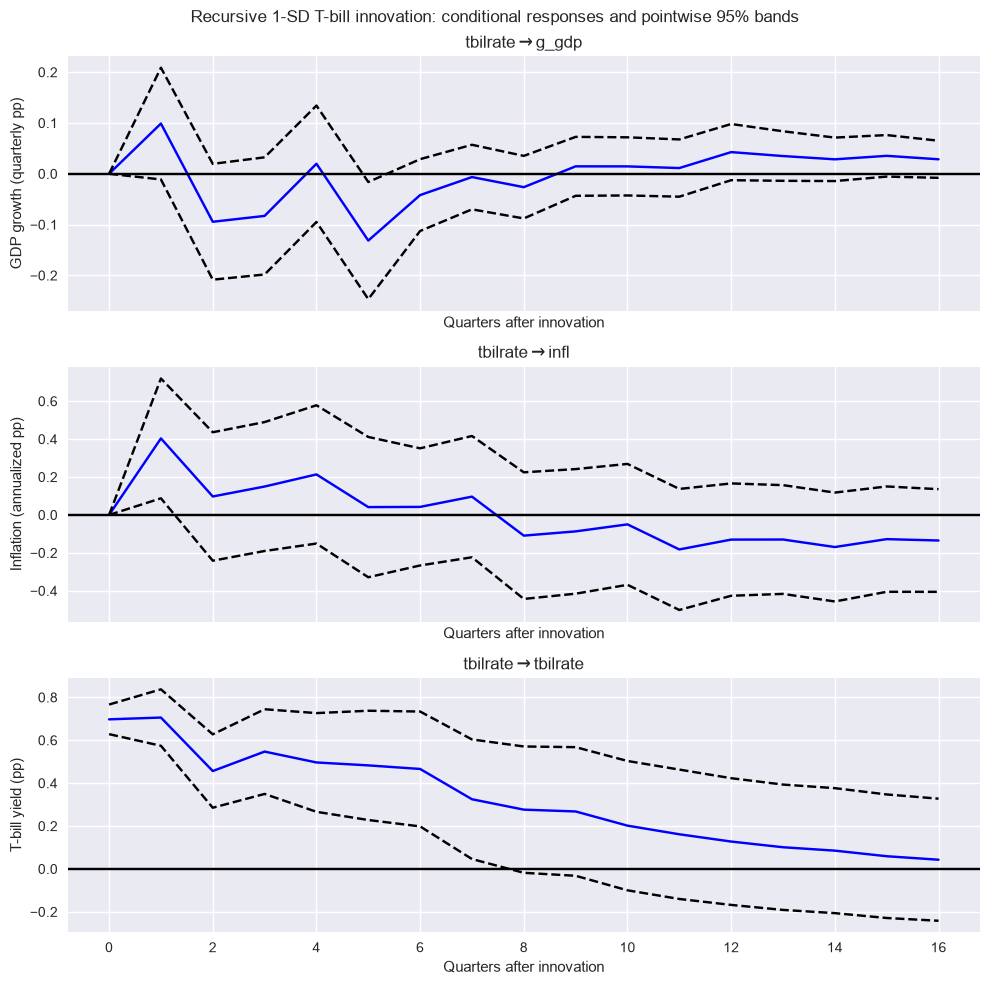

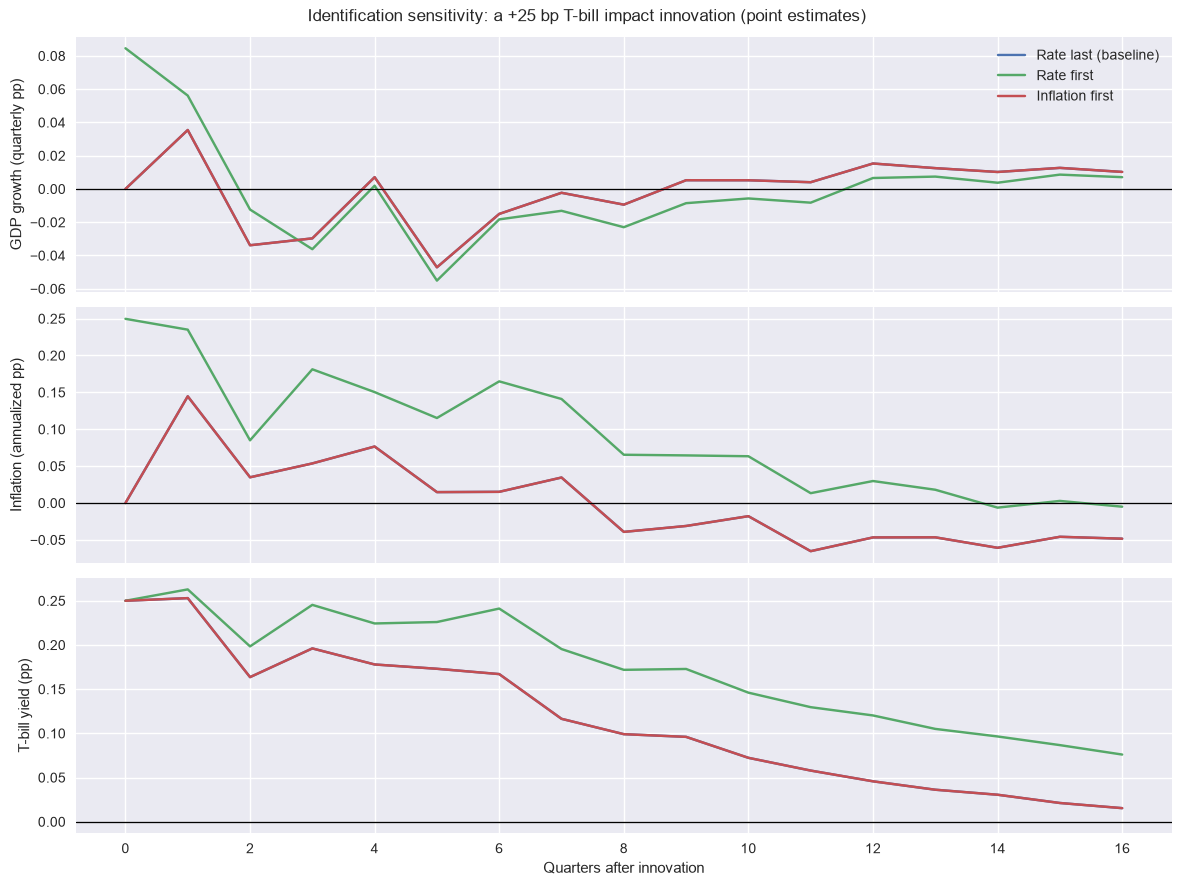

In [34]:
svar_res = VAR(monetary).fit(maxlags=CFG.maxlags, ic='aic')
print('Full-sample explanatory monetary VAR; AIC lag:', svar_res.k_ar)
monetary_diagnostics = var_diagnostics(svar_res, 'Monetary VAR')
export_table(monetary_diagnostics, 'monetary_var_diagnostics')
monetary_adequate = bool(monetary_diagnostics.stable.all() and
                         not monetary_diagnostics.reject_no_autocorrelation.any())
print('Passes these limited adequacy screens:', monetary_adequate)

IRF_STEPS = 16
irf = svar_res.irf(IRF_STEPS)
fig = irf.plot(orth=True, impulse='tbilrate', signif=.05)
units = ['GDP growth (quarterly pp)', 'Inflation (annualized pp)', 'T-bill yield (pp)']
for ax, label in zip(fig.axes, units):
    ax.set_ylabel(label)
    ax.set_xlabel('Quarters after innovation')
fig.suptitle('Recursive 1-SD T-bill innovation: conditional responses and pointwise 95% bands')
save_figure('monetary_irf', fig)

# Compare identifying assumptions at a COMMON impact size, not different 1-SD shocks.
orders = {
    'Rate last (baseline)': ['g_gdp', 'infl', 'tbilrate'],
    'Rate first': ['tbilrate', 'g_gdp', 'infl'],
    'Inflation first': ['infl', 'g_gdp', 'tbilrate'],
}
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
ordering_rows = []
for label, order in orders.items():
    result = VAR(monetary[order]).fit(svar_res.k_ar)
    shock = order.index('tbilrate')
    response = result.irf(IRF_STEPS).orth_irfs[:, :, shock]
    response = response * (.25 / response[0, shock])  # 25 basis points = 0.25 pp
    np.testing.assert_allclose(response[0, shock], .25)
    for ax, name, unit in zip(axes, monetary, units):
        values = response[:, order.index(name)]
        ax.plot(range(IRF_STEPS+1), values, label=label)
        ax.set_ylabel(unit); ax.axhline(0, color='black', lw=.8)
        ordering_rows.extend({'ordering': label, 'response': name, 'quarter': h, 'value': value}
                             for h, value in enumerate(values))
axes[0].legend(); axes[-1].set_xlabel('Quarters after innovation')
fig.suptitle('Identification sensitivity: a +25 bp T-bill impact innovation (point estimates)')
save_figure('monetary_ordering_sensitivity', fig)
ordering_results = pd.DataFrame(ordering_rows)
ordering_results.to_csv(OUT / 'monetary_ordering_sensitivity.csv', index=False)

This is a reduced-form VAR plus Cholesky restrictions, which implements a recursive SVAR.
The one-standard-deviation figure uses pointwise asymptotic bands conditional on the model and
ordering; they exclude identification and specification uncertainty. The rate stationarity
ambiguity and rejected residual-whiteness tests undermine an unconditional interpretation.
The ordering comparison uses a common +25 bp impact size and shows point estimates only.
Swapping growth and inflation while leaving the rate last gives the same rate innovation in
this unrestricted VAR, so those two response curves overlap. Moving the rate first changes it.

GDP growth is quarterly while inflation is annualized. A GDP-growth response is not a GDP-level
response; cumulating growth would be needed for the latter. A positive inflation response may
reflect omitted information, but this exercise does not diagnose the price puzzle's mechanism.
Adding variables would not automatically repair identification. No policy effect is established.

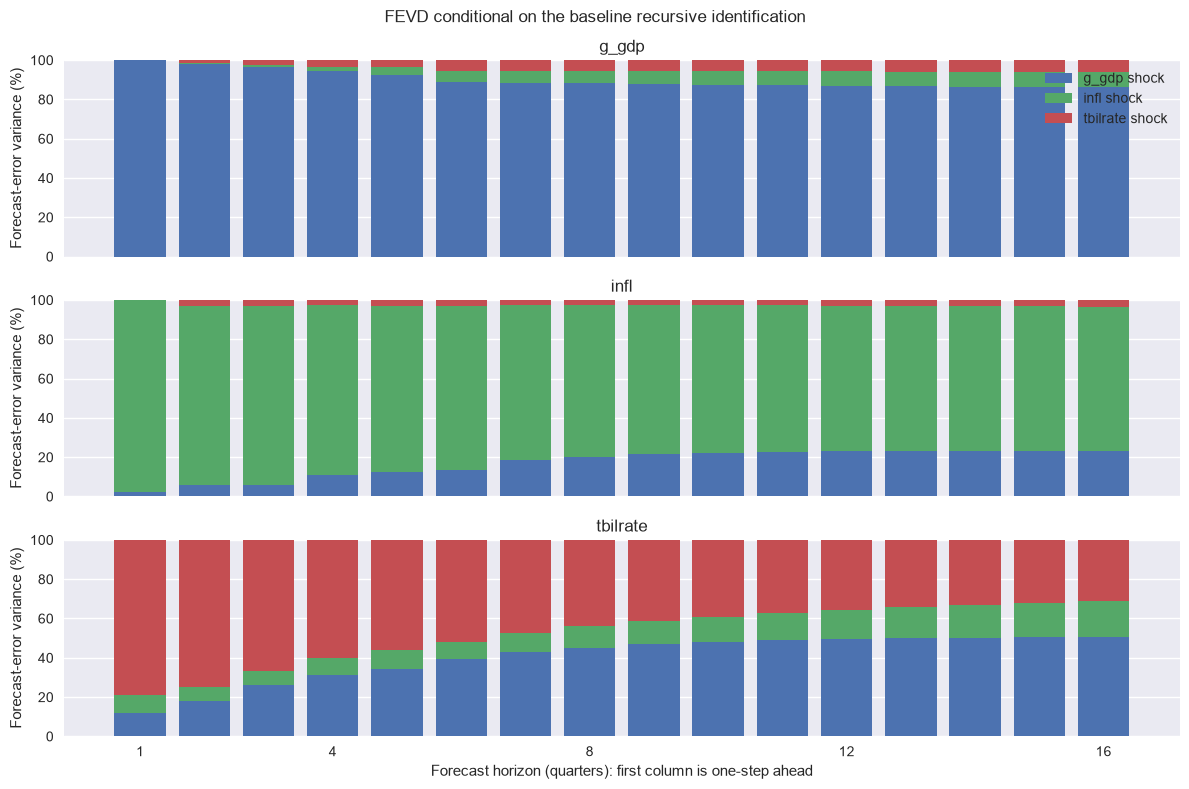

,response,horizon_quarters,shock,share
96,tbilrate,1,g_gdp,0.118660
111,tbilrate,16,g_gdp,0.503917
112,tbilrate,1,infl,0.093381
127,tbilrate,16,infl,0.183636
128,tbilrate,1,tbilrate,0.787959
143,tbilrate,16,tbilrate,0.312447


In [35]:
fevd = svar_res.fevd(IRF_STEPS)
shares = fevd.decomp  # response variable × forecast horizon × identified shock
np.testing.assert_allclose(shares.sum(axis=2), 1.0, atol=1e-10)
horizons = np.arange(1, IRF_STEPS+1)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fevd_rows = []
for i, (ax, response) in enumerate(zip(axes, monetary)):
    bottom = np.zeros(IRF_STEPS)
    for j, shock in enumerate(monetary):
        values = 100 * shares[i, :, j]
        ax.bar(horizons, values, bottom=bottom, label=f'{shock} shock')
        bottom += values
        fevd_rows.extend({'response': response, 'horizon_quarters': h, 'shock': shock,
                          'share': value} for h, value in zip(horizons, shares[i, :, j]))
    ax.set_title(response); ax.set_ylabel('Forecast-error variance (%)'); ax.set_ylim(0, 100)
axes[0].legend(loc='upper right')
axes[-1].set_xlabel('Forecast horizon (quarters): first column is one-step ahead')
axes[-1].set_xticks([1, 4, 8, 12, 16])
fig.suptitle('FEVD conditional on the baseline recursive identification')
save_figure('monetary_fevd', fig)
fevd_table = pd.DataFrame(fevd_rows)
fevd_table.to_csv(OUT / 'monetary_fevd.csv', index=False)
display(fevd_table.query('response == "tbilrate" and horizon_quarters in [1, 16]'))

The first column represents one-step-ahead error variance, not horizon zero. About 78.8% of
that T-bill variance is attributed to its own identified innovation; this share is not imposed
to equal one. A variable ordered last can respond immediately to the earlier shocks. At 16
quarters its own share is approximately 31.2%. These are shares of forecast-error variance under
the identification, not proof that a variable is fundamentally a cause or an effect.